# An alternative BAO pipeline: AP parameters without assuming a template

**The question.** A standard BAO analysis takes the *shape and phase* of the BAO wiggles from a
fiducial cosmology and lets the broadband float. Can we instead leave the whole linear spectrum
free — no fiducial cosmology anywhere — and still measure the distance scale? And does the
bispectrum help?

**What is measurable, and why.** The model has an exact symmetry $g_1$: rescale $h_{\rm conv}$,
every $D_A$ and every $1/H$ by the same factor and no observable changes at all (pybird's AP
carries the full volume factor, so the Mpc$/h$ ruler length and a common rescaling of all
distances are literally the same parameter). Absolute $D_A$ and $H$ are therefore *not* measurable
— exactly as in a real BAO analysis, which measures distances only in units of $r_d$. What is
invariant under $g_1$, and so measurable, is
$$\alpha_\perp \equiv \ln D_A - \ln h_{\rm conv} = D_M/r_d, \qquad
  \alpha_\parallel \equiv -\ln H - \ln h_{\rm conv} = D_H/r_d,$$
where the "ruler" is the template's own BAO feature. $F_{\rm AP} = D_M/D_H$ needs no ruler at all.

**The three stages of this notebook.**

1. **No assumptions.** The template is completely free. The wiggles can move with it, so the ruler
   floats: $D_M/r_d$ is not measurable. What survives is $F_{\rm AP}$, the distance *ratios*
   between redshifts, and $f$.
2. **The model we actually sample.** Adding the smoothness prior of the HMC gets $D_M/r_d$ to
   ~2%, but the template can still slide its own wiggles by 3% — so that "2%" is largely the
   prior's ruler, not the data's.
3. **A phase prior.** Forbid the template from moving the wiggles, while leaving the broadband
   and the wiggle *amplitude* completely free. That is precisely the assumption a standard BAO
   analysis makes, and it brings $D_M/r_d$ to 0.9% — pre-reconstruction BAO precision on the same
   mock.

The data, likelihood and Jacobian are the same as in `08_growth_pk_bk.ipynb`; see there for how
the Fisher is built.

In [1]:
import os, sys
os.chdir(os.path.dirname(os.path.abspath('.')) if os.path.basename(os.getcwd()) != 'fisher'
         else os.getcwd())
sys.path.insert(0, os.getcwd())
import numpy as np
R = np.load('../../output/fisher_pb/jacobians_pb.npz', allow_pickle=True)
print(f"redshift bins: {np.round(R['zeff_unique'], 3).tolist()}   ({int(R['num_skies'])} skies, "
      f"sky -> z index {R['sky_to_z_idx'].tolist()})")
print(f"free parameters per data set: {R['J_p'].shape[1]} (P)   {R['J_pb'].shape[1]} (P+B)")
print(f"   = per-sky EFT ({len(R['eft_names_p'])} P / {len(R['eft_names_pb'])} P+B names x "
      f"{int(R['num_skies'])} skies) + {int(R['n_knots'])} template amplitudes + "
      f"{int(R['n_growth'])} growth/geometry")
print(f"data vector: {R['J_p'].shape[0]} bins (P0,P2,P4)   {R['J_pb'].shape[0]} bins (+B0: "
      f"{int(R['isB_pb'].sum())} triangles)")
print(f"exact-symmetry check, delta chi^2 along g1/g2/g3 for a 1% move "
      f"(0 = exact): {np.round(R['sym_tests_pb'][0][:3], 4).tolist()}")

redshift bins: [0.295, 0.51, 0.706, 0.93, 1.317, 1.491]   (7 skies, sky -> z index [0, 1, 2, 3, 3, 4, 5])
free parameters per data set: 203 (P)   217 (P+B)
   = per-sky EFT (14 P / 16 P+B names x 7 skies) + 80 template amplitudes + 25 growth/geometry
data vector: 399 bins (P0,P2,P4)   1316 bins (+B0: 917 triangles)
exact-symmetry check, delta chi^2 along g1/g2/g3 for a 1% move (0 = exact): [0.001, 2.0587, 0.005]


## 1. Stage A — no assumptions at all

All 80 template knots free, **no prior on the template whatsoever**, everything marginalized
(the numbers come from `robust_marg_pb.py`, which does this case with an SVD because the system is
genuinely degenerate and no covariance matrix exists along the flat directions).

In [2]:
S = np.load('../../output/fisher_pb/robust_pb_results.npz')
z = S['zeff']; iz = 2
print(f"Fully free 80-knot template, no prior, everything marginalized (z = {z[iz]:.3f}):\n")
print(f"{'':34s}{'P(k)':>12s}{'P(k)+B(k)':>12s}")
rows = [('D_M/r_d  (absolute distance)', 'alpha_perp'), ('F_AP = D_M/D_H', 'F_AP'),
        ('isotropic distance vs z=0.93', 'alpha_iso_rel'), ('growth rate f', 'f')]
for lab, key in rows:
    a, b = S[f'geo_free_free_p_{key}'][iz], S[f'geo_free_free_pb_{key}'][iz]
    fmt = lambda v: ('not measured' if v > 1 else f'{100*v:.2f}%')
    print(f"  {lab:32s}{fmt(a):>12s}{fmt(b):>12s}")
print(f"\n  BAO wiggle detection S/N          {S['snr_free_p_marg'][0]:11.1f}"
      f"{S['snr_free_pb_marg'][0]:12.1f}")
print("\nThe distance SCALE is unmeasurable: with a free template the wiggles move with it, so"
      "\nthe model carries its own ruler. What survives is the AP ratio and the distances"
      "\nRELATIVE to one redshift -- and the bispectrum improves both by ~40%, while turning f"
      "\nfrom unmeasured into a 19% measurement.")

Fully free 80-knot template, no prior, everything marginalized (z = 0.706):

                                          P(k)   P(k)+B(k)
  D_M/r_d  (absolute distance)    not measurednot measured
  F_AP = D_M/D_H                         5.05%       3.15%
  isotropic distance vs z=0.93           1.28%       1.04%
  growth rate f                   not measured      18.95%

  BAO wiggle detection S/N                  9.4        12.5

The distance SCALE is unmeasurable: with a free template the wiggles move with it, so
the model carries its own ruler. What survives is the AP ratio and the distances
RELATIVE to one redshift -- and the bispectrum improves both by ~40%, while turning f
from unmeasured into a 19% measurement.


## 2. Stage B — the model we sample, and why its ruler is the prior's

The HMC model puts $\ln a$ on 60 nodes, spaced 0.15 in $\ln k$, with a smoothness prior
$\lambda = 200$. A BAO oscillation spans $2\pi/(r_d k)$ in $\ln k$ — 1.2 at $k = 0.05$, 0.6 at 0.1,
0.3 at $0.2\ h/$Mpc — so there are about four nodes per wiggle and the basis can reproduce a
wiggle *shift* almost perfectly.

Concretely: write $T = T_{\rm nw}(1+O)$, with $T_{\rm nw}$ the smooth part and $O$ the wiggles.
Sliding the wiggle pattern by $\delta$ in $\ln k$ changes the spectrum by
$$\Delta \ln P = \delta\, v(k), \qquad v \equiv \frac{{\rm d}\ln(1+O)}{{\rm d}\ln k}.$$
If $\ln a$ can contain $v$, the fit cannot tell a template slide from a change in distance. The
figure shows $v$ and how much of it each basis can represent: **96% for the 60-node basis we
sample, 16% for a basis with one node per BAO period**.

In [3]:
%run meeting_bao_pb.py

BAO period in ln k = 2pi/(r_d k): 1.20 at k=0.05, 0.60 at 0.1, 0.30 at 0.2 h/Mpc
slide pattern v = dln(1+O)/dlnk represented by the node basis: 95.7% at spacing 0.15 (60 nodes), 16.4% at spacing 0.60 (16 nodes)
smoothness prior alone allows a template slide of 3.16% (1 sigma) in the 60-node basis -> that is the ruler the current model really has



saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_phase_prior_explained.png


z = 0.706: fractional 1 sigma vs the phase prior (sigma_delta = how far the template may slide its own wiggles, 6 envelope modes)
 sigma_delta       D_M/r_d  P     P+B       D_H/r_d  P     P+B       F_AP  P      P+B        f  P      P+B
        free       2.13%    1.94%       2.37%    2.17%       1.62%    1.59%      18.46%    9.65%
       5.00%       1.92%    1.76%       2.21%    2.03%       1.61%    1.58%      18.34%    9.50%
       3.00%       1.74%    1.62%       2.06%    1.93%       1.61%    1.58%      18.33%    9.47%
       2.00%       1.54%    1.46%       1.89%    1.80%       1.60%    1.58%      18.32%    9.45%
       1.00%       1.19%    1.16%       1.60%    1.56%       1.60%    1.58%      18.30%    9.39%
       0.50%       0.97%    0.94%       1.43%    1.39%       1.60%    1.57%      18.30%    9.36%
       0.20%       0.88%    0.85%       1.35%    1.32%       1.59%    1.57%      18.30%    9.35%
       0.10%       0.86%    0.83%       1.34%    1.31%       1.59%    1.57%      18.


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_phase_scan.png

Per-redshift fractional 1 sigma:
  no phase prior (the model we sample)
                          z=0.29          z=0.51          z=0.71          z=0.93          z=1.32          z=1.49
    perp  P(k)                2.38%           2.20%           2.13%           2.14%           2.24%           6.12%
    perp  P(k)+B(k)           2.19%           2.02%           1.94%           1.96%           2.05%           6.04%
    par   P(k)                3.12%           2.56%           2.37%           2.29%           2.41%           7.27%
    par   P(k)+B(k)           2.92%           2.36%           2.17%           2.11%           2.27%           7.15%
    F_AP  P(k)                2.90%           2.01%           1.62%           1.48%           1.80%           9.24%
    F_AP  P(k)+B(k)           2.85%           1.98%           1.59%           1.46%          

saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_bao_per_z.png


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_bao_corner.png


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_bao_triangle_all_z.png


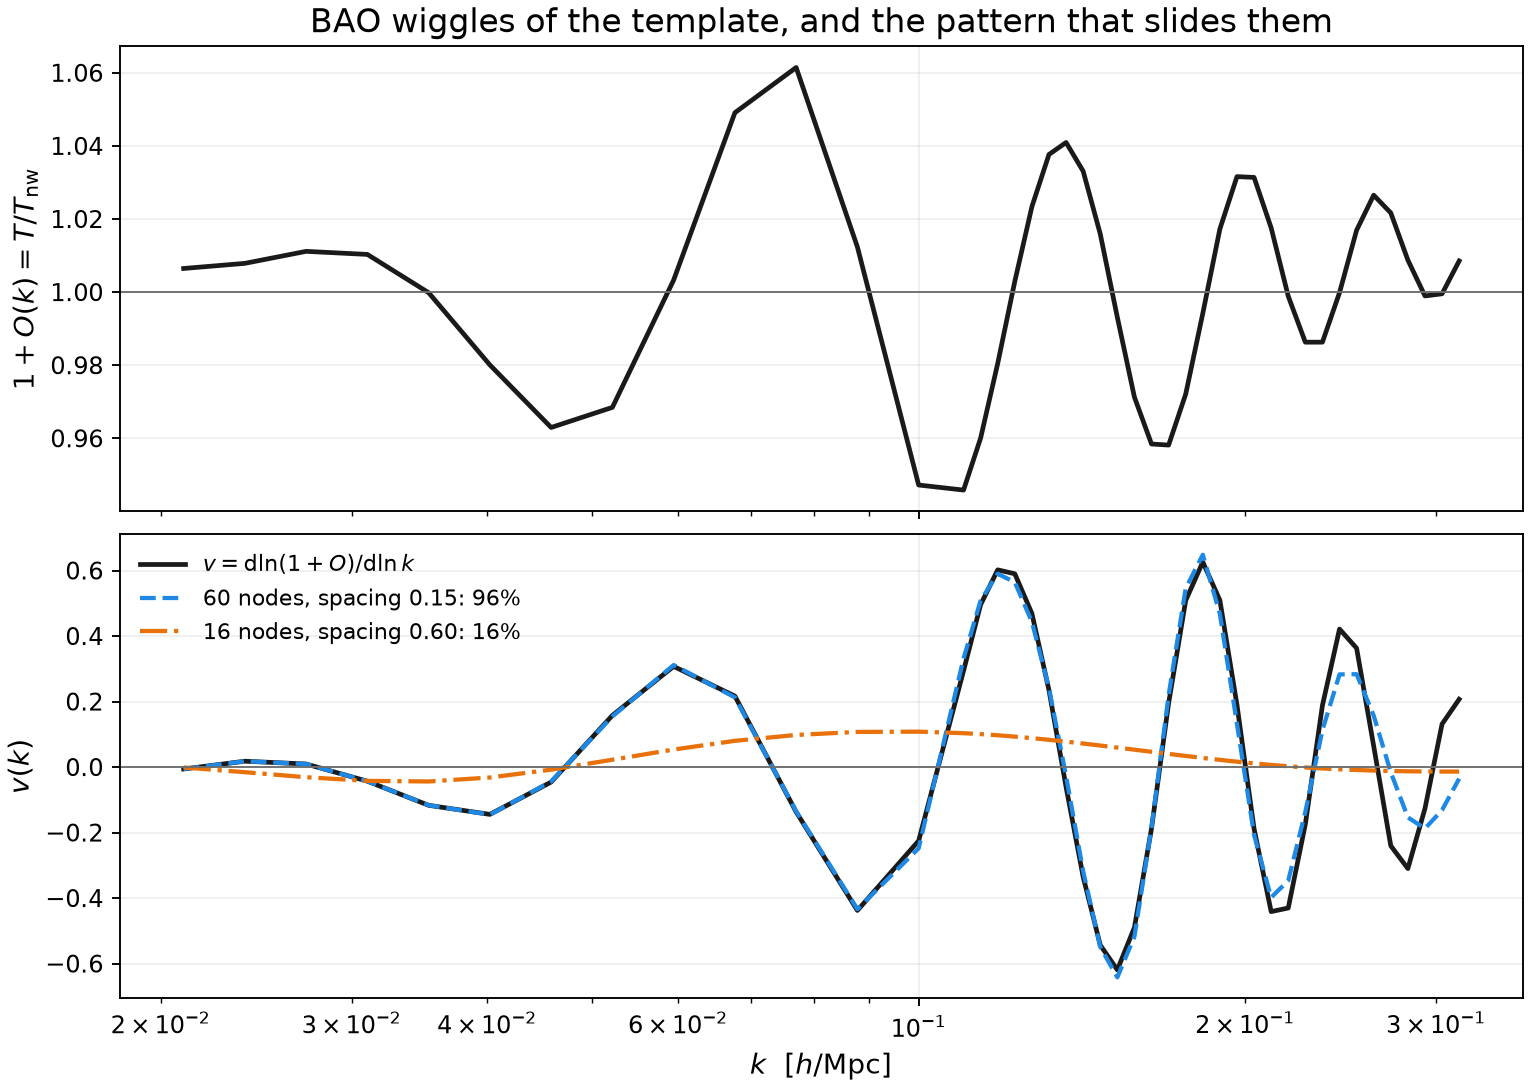

In [4]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_phase_prior_explained.png', width=860))

## 3. Stage C — the phase prior, and how it is implemented

The assumption a standard BAO analysis makes is: *the broadband is free, the wiggle phase is not*.
Here that is one Gaussian prior, on the component of $\ln a$ along $v$:

$$\ln a = \delta(k)\,v(k) + (\text{the rest}), \qquad
  \delta(k) = \sum_{j=0}^{5} c_j P_j(\ln k), \qquad
  c_j \sim \mathcal{N}(0, \sigma_\delta^2).$$

$\sigma_\delta$ is literally *how far the template is allowed to move the ruler*, in per cent. One
global slide ($j = 0$ alone) is **not** enough — the template can drift the phase slowly across the
band and take most of the freedom back — so the prior covers $v$ times Legendre envelopes of degree
0–5 over $0.01 < k < 0.4\ h/$Mpc: the phase is pinned *everywhere*, not just on average. The wiggle
**amplitude is never touched**: it is the damping nuisance of a BAO fit and stays free, as does the
entire broadband.

For reference, the smoothness prior alone allows a 3.2% slide — which is why stage B's "2%"
distance was really the prior's ruler.

In [5]:
import inspect, mi_prior_fisher as M
print(inspect.getsource(M.phase_modes))
print(inspect.getsource(M.phase_precision))

def phase_modes(Sb, n_phase=N_PHASE):
    """The wiggle-slide patterns, on the ln-a nodes of basis `Sb`: columns v * P_j(ln k).

    A single column (n_phase = 1) pins one GLOBAL slide of the wiggle pattern. That is not
    enough: the template can still drift the phase slowly across k and recover most of the
    freedom (measured: sigma(D_M/r_d) 2.13% -> 1.37% only). The envelopes P_j are Legendre
    polynomials of degree j in ln k rescaled to [-1, 1] over PHASE_RANGE, so column j is a
    slide whose size varies across the band; pinning j = 0..5 leaves the phase fixed
    everywhere and takes sigma(D_M/r_d) to 0.88%, close to the 0.71% of a basis too coarse to
    slide anything. The wiggle AMPLITUDE is never touched -- it is the damping nuisance of a
    BAO fit and stays free."""
    from numpy.polynomial.legendre import legval
    lo, hi = np.log(PHASE_RANGE[0]), np.log(PHASE_RANGE[1])
    x = np.clip((np.log(knots_h) - lo) / (hi - lo) * 2 - 1, -1, 1)
    cols = []
    for j in r

### Tightening the prior

Left and centre: as $\sigma_\delta$ shrinks, the distances sharpen and then saturate — once the
template can no longer move the ruler, the data's own BAO feature sets the error. Right: pinning
the phase with more envelope modes converges toward the dashed line, which is a basis too coarse
to slide anything at all.

The saturated value is what this method delivers: **$D_M/r_d$ to 0.88% and $D_H/r_d$ to 1.35% at
$z = 0.71$ from P(k) alone**, against 0.65% and 1.53% for a standard pre-reconstruction BAO fit on
the same mock (Seo & Eisenstein 2007, the formula DESI's design forecasts used). The
model-independent analysis is slightly worse on $D_M$ and slightly *better* on $D_H$, with a
completely free broadband.

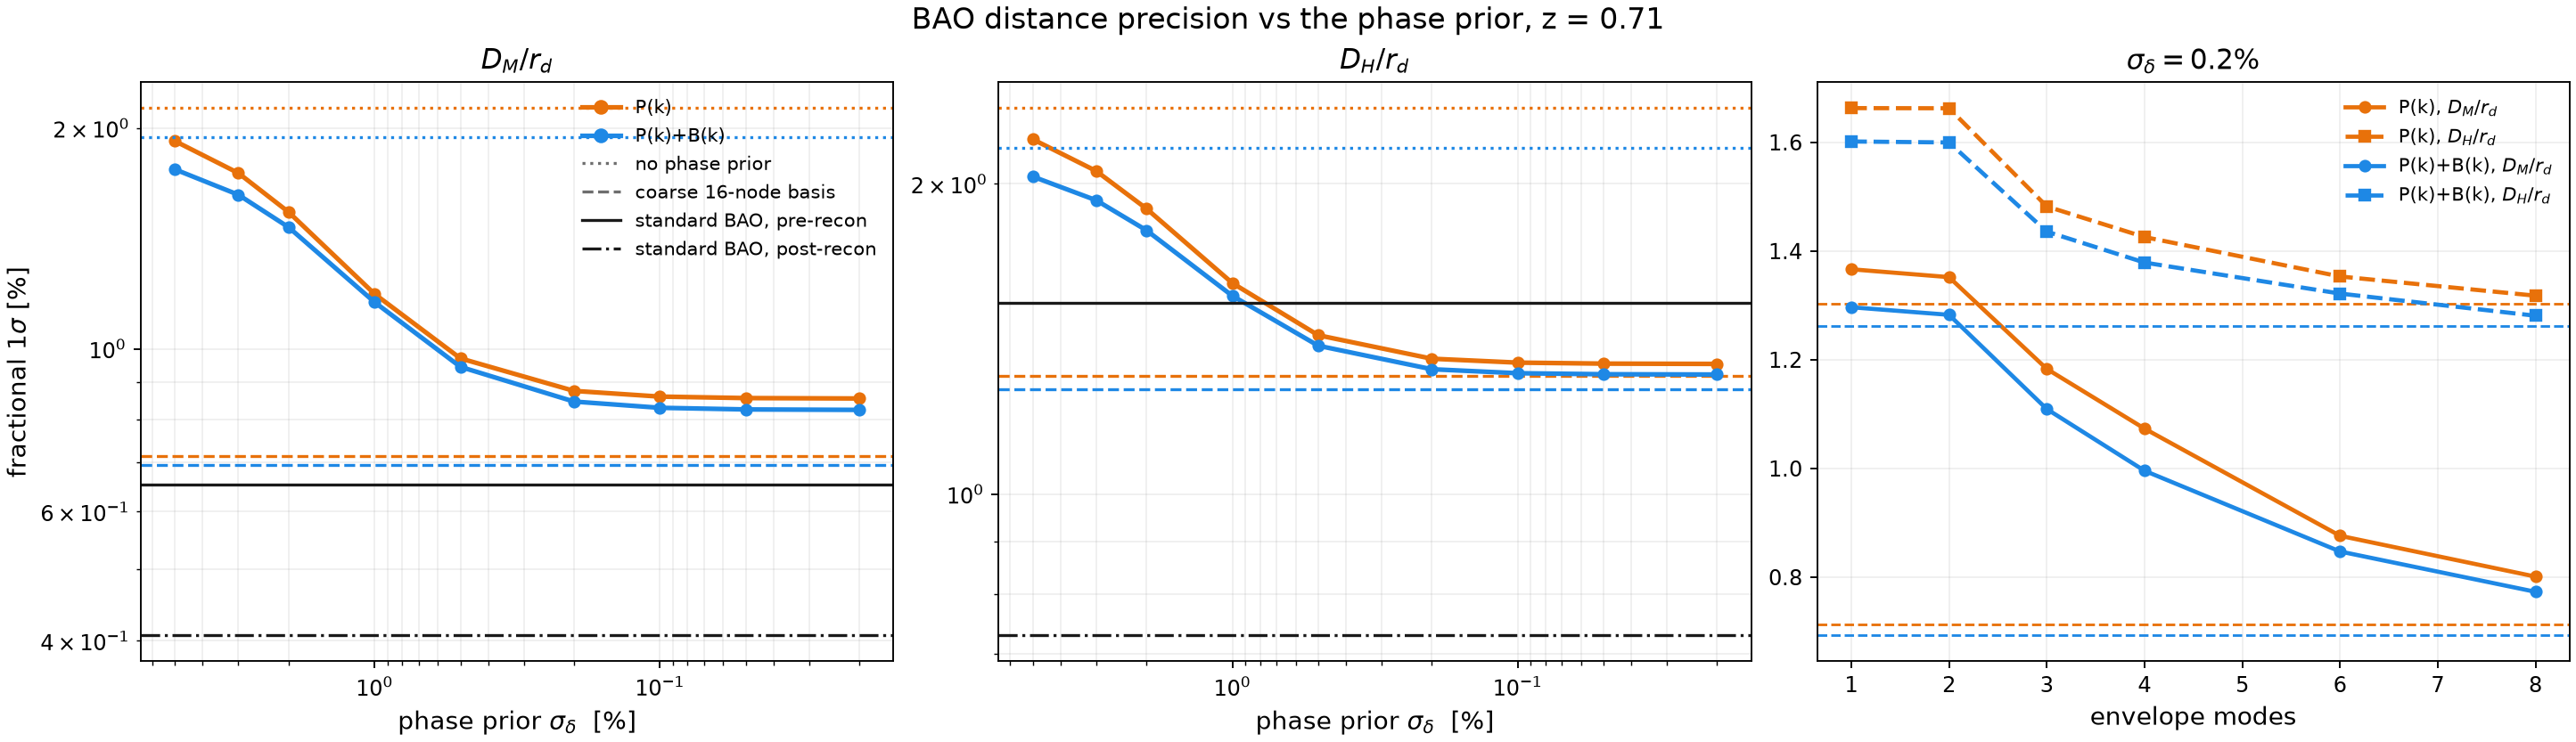

In [6]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_phase_scan.png', width=1150))

## 4. P(k) vs P(k)+B(k), at every redshift

Solid: the model we sample (no phase prior). Dashed: with the phase prior. Grey: standard BAO,
pre- and post-reconstruction, on the same bins.

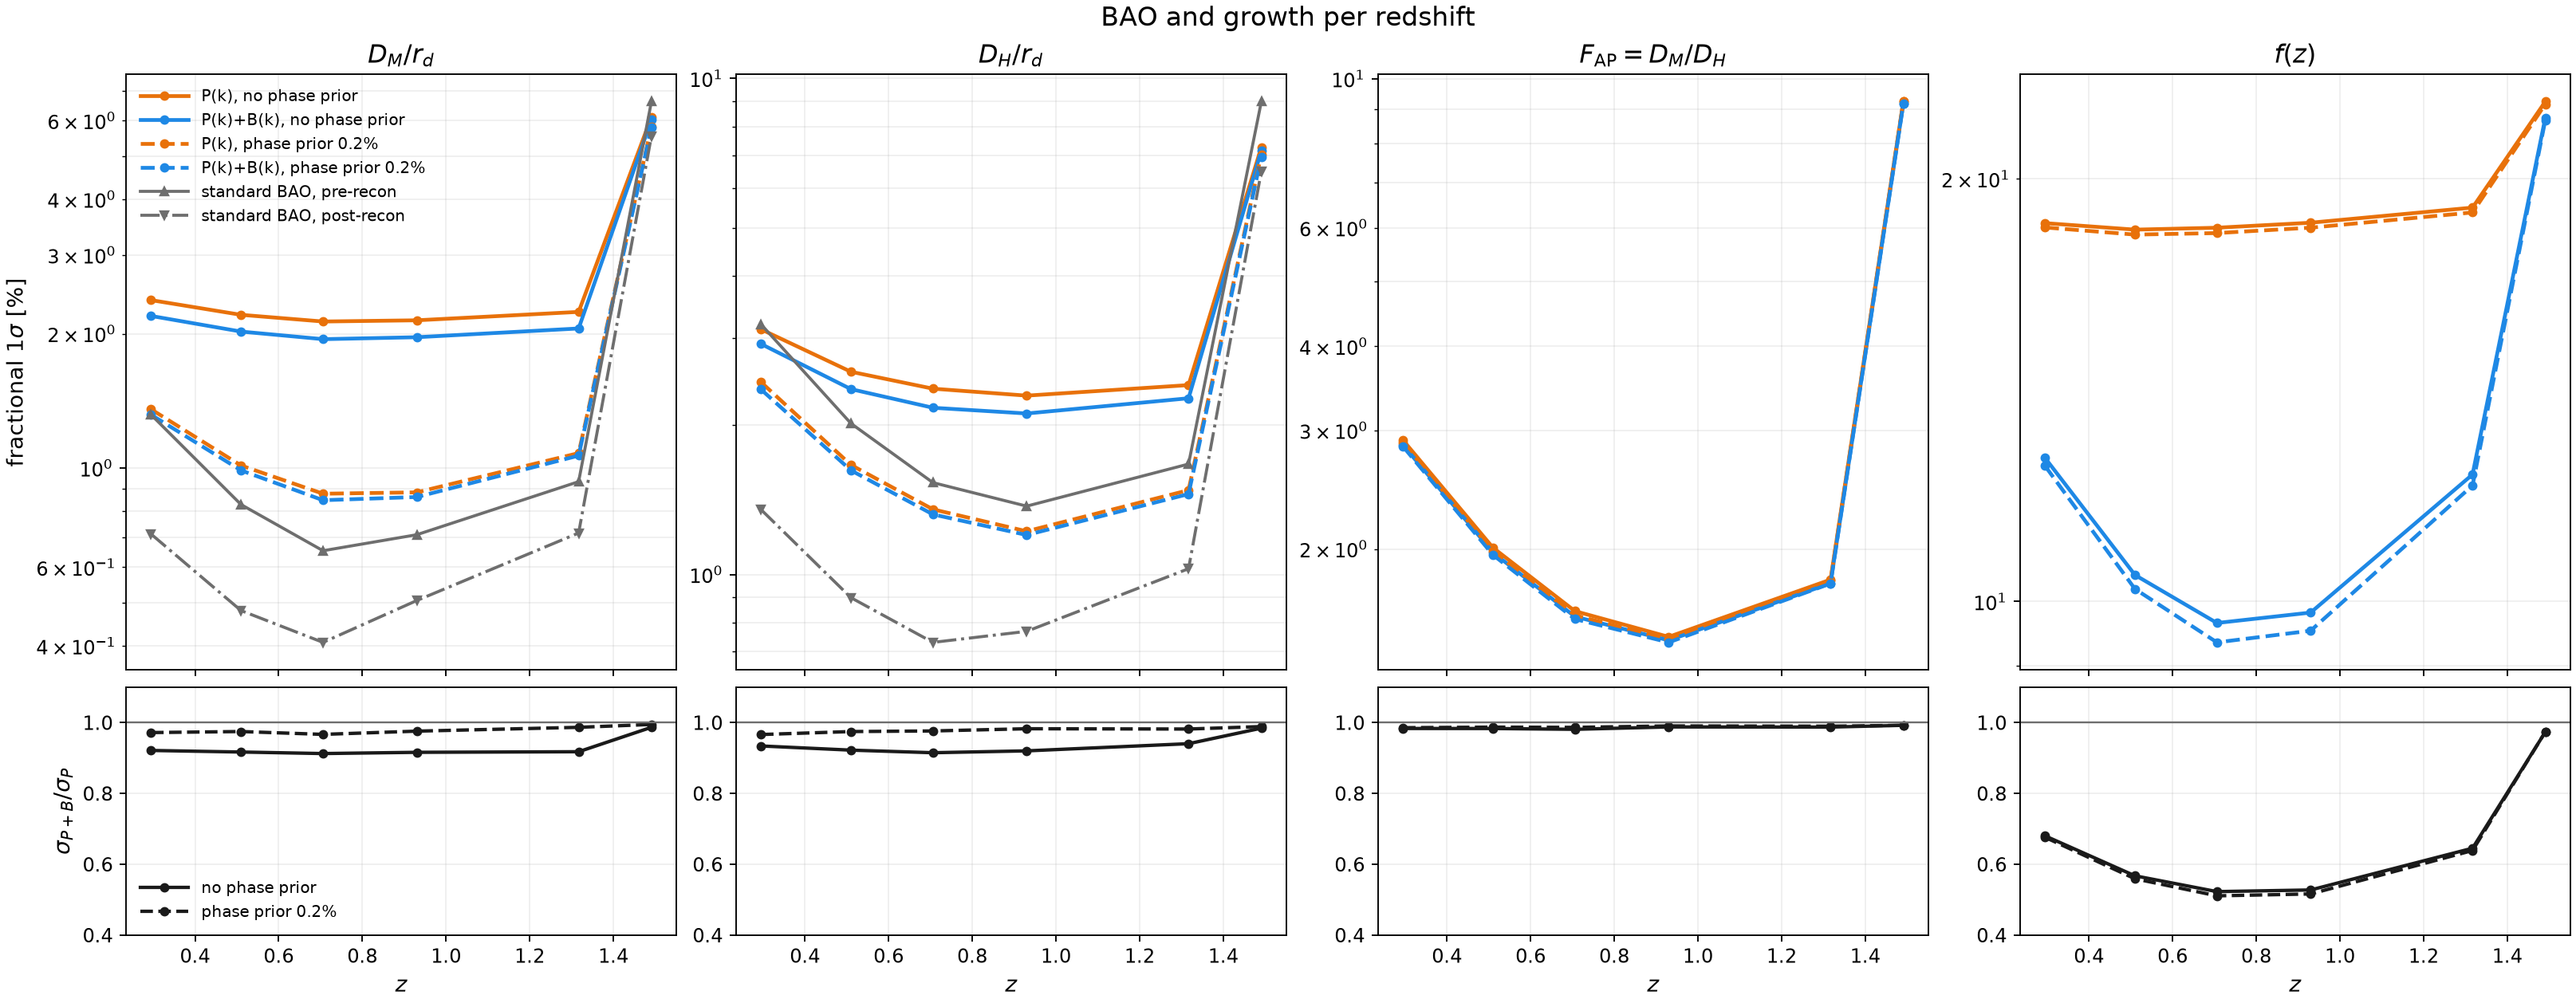

In [7]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_bao_per_z.png', width=1150))

### All twelve BAO parameters at once

$D_M/r_d$ and $D_H/r_d$ at every redshift, with the phase prior, everything else marginalized.
The off-diagonal panels are what a single-redshift plot cannot show: the redshift bins are
correlated, because they share one template, one set of EFT priors and one $h_{\rm conv}$.

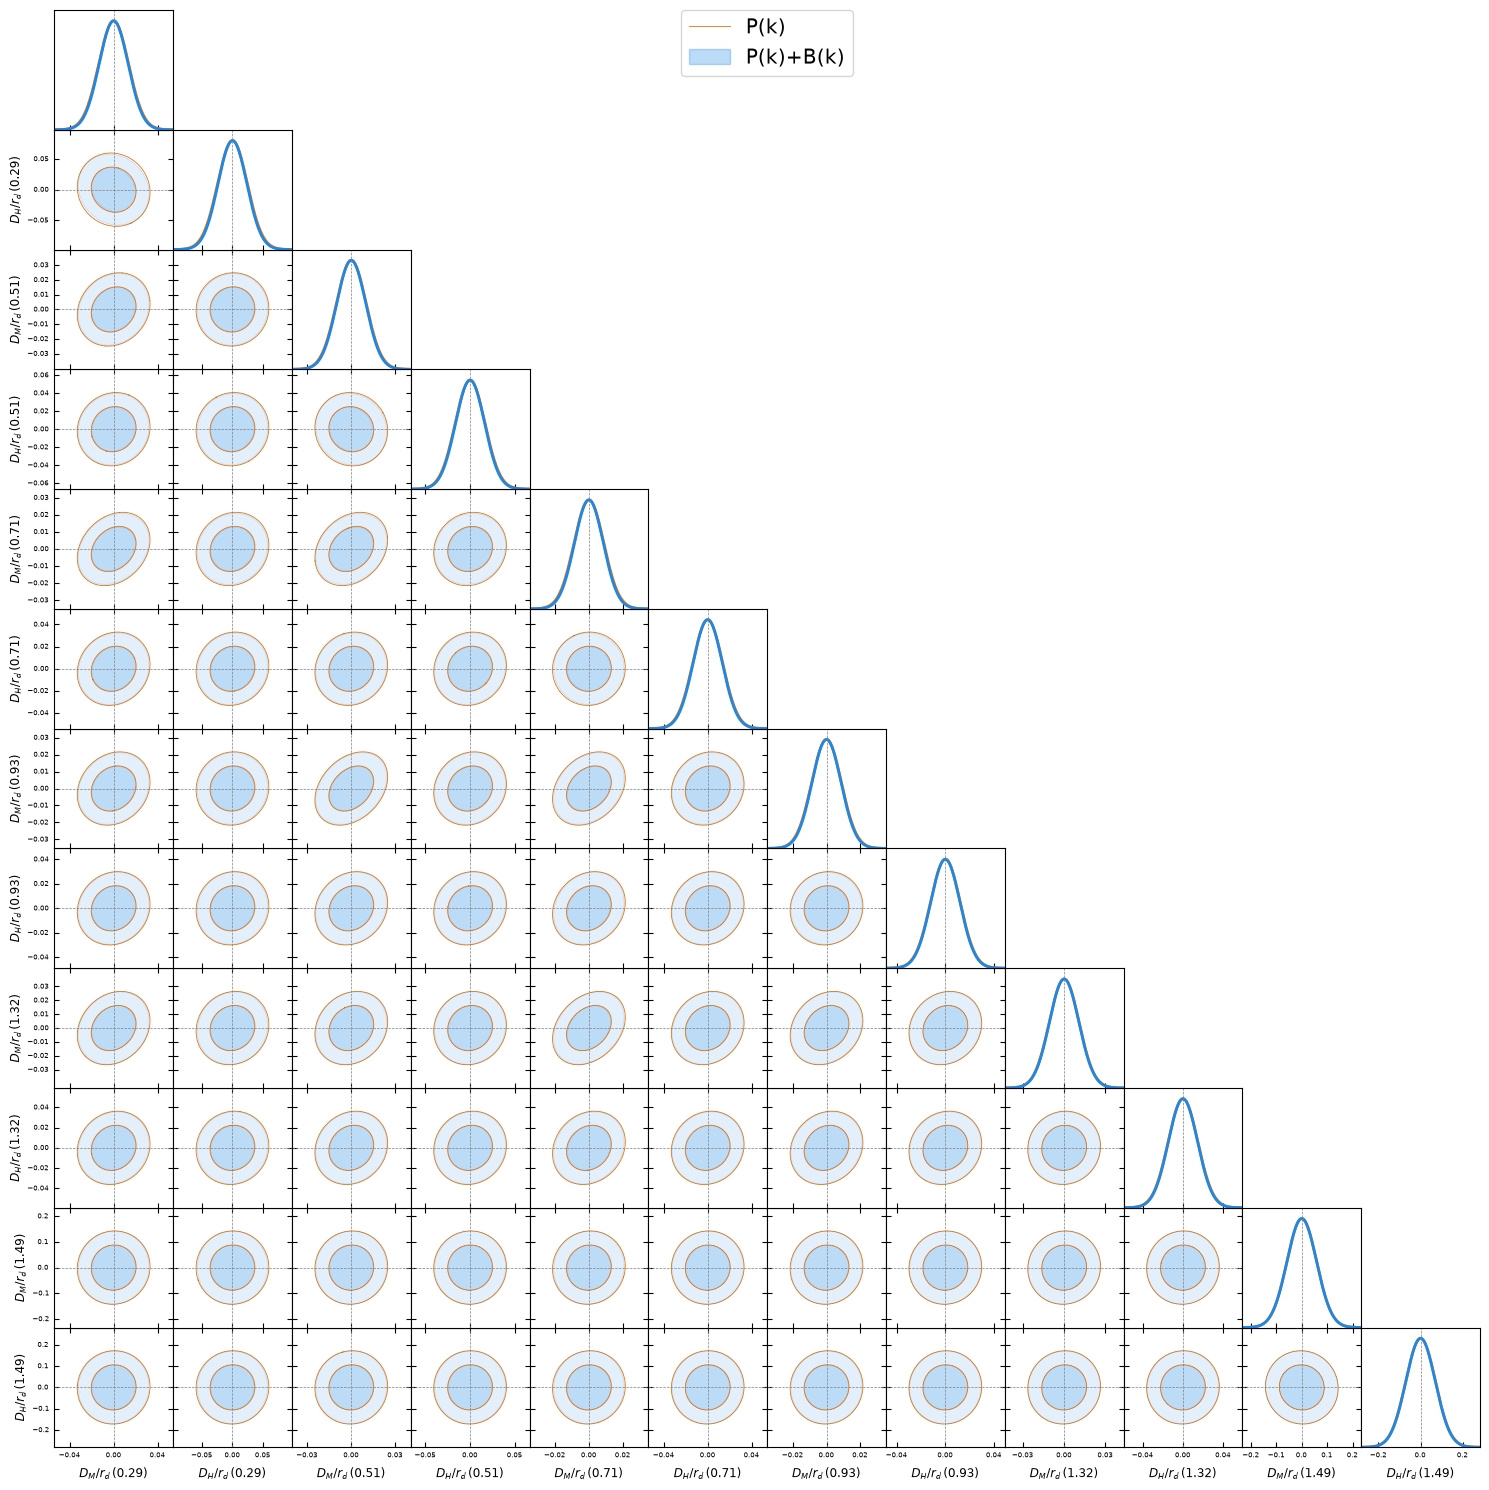

In [8]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_bao_triangle_all_z.png', width=1250))

### One redshift in detail

The same at $z = 0.71$ only, with the growth rate, and with the no-phase-prior case for contrast.

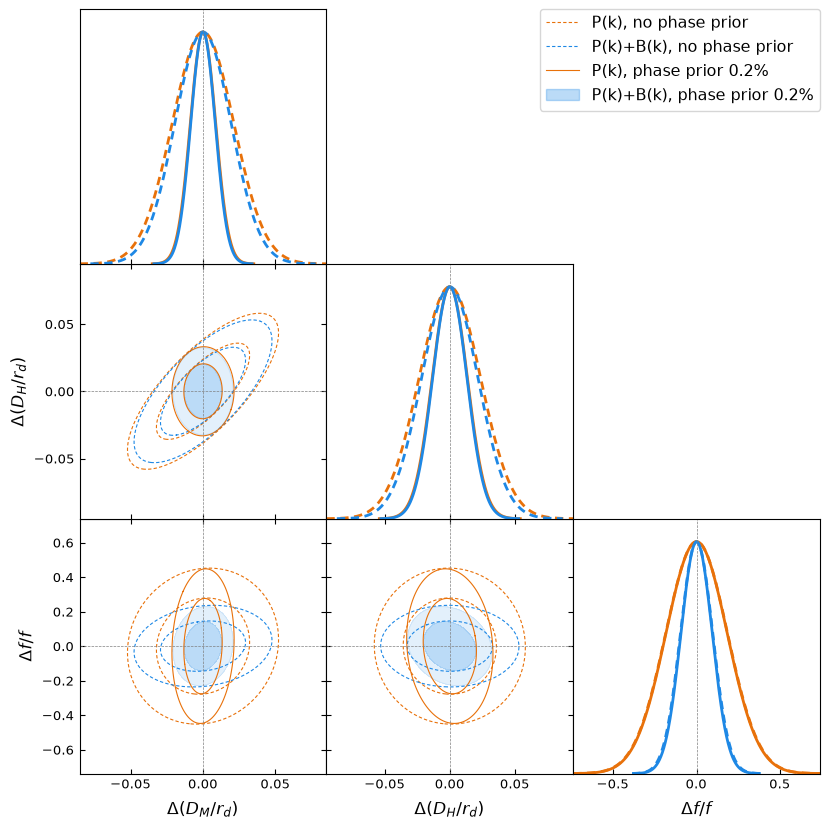

In [9]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_bao_corner.png', width=760))

## Summary

At $z = 0.71$, fractional $1\sigma$:

| | $D_M/r_d$ | $D_H/r_d$ | $F_{\rm AP}$ | $f$ |
|---|---|---|---|---|
| free template, no prior | not measurable | not measurable | 5.1% → 3.2% | — → 19% |
| + smoothness prior (what we sample) | 2.13% → 1.94% | 2.37% → 2.17% | 1.62% → 1.59% | 18.5% → 9.7% |
| **+ phase prior 0.2%** | **0.88% → 0.85%** | **1.35% → 1.32%** | 1.59% → 1.57% | 18.3% → 9.4% |
| coarse 16-node basis (rigid by construction) | 0.71% → 0.69% | 1.30% → 1.26% | 1.58% → 1.55% | 18.5% → 9.6% |
| standard BAO, pre-reconstruction | 0.65% | 1.53% | — | — |
| standard BAO, post-reconstruction | 0.41% | 0.73% | — | — |

*(each cell: P(k) → P(k)+B(k))*

**Reading.**

* With a genuinely free template there is no distance scale — the template carries its own ruler.
  This is not a numerical problem; it is the exact statement that the data cannot separate a
  wiggle shift from a distance.
* One explicit prior — the wiggles may slide by at most $\sigma_\delta$ — recovers
  pre-reconstruction BAO precision while leaving the broadband entirely free. This is the
  *minimal* form of the assumption every BAO analysis already makes, written down rather than
  implied by a fixed template.
* The bispectrum adds a few per cent on the geometry and a factor two on $f$. Its value here is
  the growth rate, not the ruler.
* The gap to post-reconstruction BAO (0.41% / 0.73%) is reconstruction, not the
  model-independent approach.

**Still to do.** A bias test (generate the mock at a shifted cosmology — $\omega_b$, $\omega_{cdm}$
or $N_{\rm eff}$ — fit with the phase prior, and check the shift in $D_M/r_d$ against $\sigma$);
an HMC run with the phase prior; and combining with post-reconstruction BAO. The honest next step
beyond a fixed phase is to marginalize over the *physical* ways the wiggle shape can change
(derivatives of $O$ with respect to $\omega_b$, $\omega_{\rm cdm}$, $N_{\rm eff}$, $n_s$ at fixed
$r_d$), which removes the fiducial-template dependence while still excluding the pure dilation
that is being measured.